# SETUP

In [1]:
# Cell 0 — CONFIG
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2
import sys, os
from dotenv import load_dotenv
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
sys.path.insert(0, str(project_root / "src" / "Experiments" / "templates"))
from A_Config import (
    set_case, case_dir, source_dir, query_dir, sam3_masks_dir,
    frames_for_cam_poses_dir, frames_for_recon_dir, vggt_o_output_dir,
    predictions_path, ply_dir, reg_dir, csv_path_gps, csv_path_pose,
    assets_dir,
)

print("project_root:", project_root)
print(project_root, project_root.exists())
load_dotenv(project_root / ".env")
case_name = "304_met_multi_4"
experiment = "subject_isolation_redacted_removed"
asset_name = f"{case_name}_{experiment}"
set_case(case_name, experiment)

case_dir_ = case_dir()
source_dir_ = source_dir()
query_dir_ = query_dir()
masks_dir = sam3_masks_dir()
frames_for_cam_poses = frames_for_cam_poses_dir()
frames_for_recon = frames_for_recon_dir()
VGGT_O_output_dir = vggt_o_output_dir()
ply_dir_ = ply_dir()
reg_dir_ = reg_dir()
csv_path_GPS = csv_path_gps()
csv_path_pose_ = csv_path_pose()

FRAME_NAME_FMT = "{:04d}.jpg"
# video loading
from Two2D.B_video_processing import video_fps
# Auto-find the video in 010_source
videos = list(source_dir_.glob("*.mp4"))
print(source_dir_)
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")
fps = video_fps(video_path)
print(f"video fps: {fps:.3f}")
import cv2; total_frames = int(cv2.VideoCapture(str(video_path)).get(cv2.CAP_PROP_FRAME_COUNT))
print("total_frames",total_frames )
#reporting
from C_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")


project_root: /workspace/project
/workspace/project True
/workspace/project/Data/304_met_multi_4/010_source
Case    : 304_met_multi_4
Video   : 04.mp4
video fps: 25.000
total_frames 609


# Manual Tracking, recon and analysis


In [2]:
from D_2d_analysis import analysis_2D
analysis_2d_for_decisions = analysis_2D(video_path, api_key)

In [ ]:
#ROBOFLOW TRACKING SAM3 MANUAL controls
sys.path.insert(0, str(project_root / "src" / "claude_agent"))
from run_models.A_ROBOFLOW_SAM3 import track_subject_sam3, run_sam3_manual
print(video_path)
analysis_2d_for_decisions.update (run_sam3_manual(video_path, "person", threshold =0.3, requested_region="us")) # add to the dict
tracker = "SAM3"
print(analysis_2d_for_decisions)



In [ ]:
#ROBOFLOW TRACKING SAM3 MANUAL controls
sys.path.insert(0, str(project_root / "src" / "claude_agent"))
from run_models.A_ROBOFLOW_SAM3 import track_subject_sam3, run_sam3_manual
print(video_path)
analysis_2d_for_decisions.update (run_sam3_manual(video_path, "police officer", threshold =0.3, requested_region="us")) # add to the dict
tracker = "SAM3"
print(analysis_2d_for_decisions)

In [ ]:
list(masks_dir.iterdir())

In [ ]:
frame_idx = 243
frame = cv2.imread(str(frames_for_recon / FRAME_NAME_FMT.format(frame_idx)))
hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
print(hsv[200, 900])  # pick x,y coords known to be on the jacket


In [ ]:
#white balancer
def white_balance_auto(frame, sat_percentile=10, val_percentile=70):
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV).astype(np.float32)
    sat, val = hsv[..., 1], hsv[..., 2]
    sat_thresh = np.percentile(sat, sat_percentile)
    val_thresh = np.percentile(val, val_percentile)
    neutral_mask = (sat <= sat_thresh) & (val >= val_thresh)
    print("neutral pixels:", neutral_mask.sum())

    if neutral_mask.sum() < 100:
        return frame

    b, g, r = frame[..., 0], frame[..., 1], frame[..., 2]
    mean_b, mean_g, mean_r = b[neutral_mask].mean(), g[neutral_mask].mean(), r[neutral_mask].mean()
    target = max(mean_b, mean_g, mean_r)

    frame_f = frame.astype(np.float32)
    frame_f[..., 0] *= target / mean_b
    frame_f[..., 1] *= target / mean_g
    frame_f[..., 2] *= target / mean_r
    out = frame_f.clip(0, 255).astype(np.uint8)
    print("changed:", not np.array_equal(frame, out))
    print("means (b,g,r):", mean_b, mean_g, mean_r)
    print("gains (b,g,r):", target/mean_b, target/mean_g, target/mean_r)
    return out



In [ ]:
#"yellow" hunter
from A_Config import FRAME_NAME_FMT

print(frames_for_recon)

def yellow_pixel_mask(frames_for_recon_dir, frame_idx, sat_thresh=100, val_thresh=100):
    frame_path = frames_for_recon_dir / FRAME_NAME_FMT.format(frame_idx)
    frame = cv2.imread(str(frame_path))
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    lower = np.array([13, sat_thresh, val_thresh])
    upper = np.array([23, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)
    out = np.zeros_like(frame)
    out[mask > 0] = frame[mask > 0]
    
    frame_bal = white_balance_auto(frame)
    hsv = cv2.cvtColor(frame_bal, cv2.COLOR_BGR2HSV)
    lower = np.array([13, sat_thresh, val_thresh])
    upper = np.array([23, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)
    out = np.zeros_like(frame_bal)
    out[mask > 0] = frame_bal[mask > 0]

    import matplotlib.pyplot as plt
    
    plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    plt.show()
    plt.imshow(cv2.cvtColor(frame_bal, cv2.COLOR_BGR2RGB))
    plt.show()
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.show()
    diff = np.clip(frame_bal.astype(np.int16) - frame.astype(np.int16), 0, 255).astype(np.uint8)
    plt.imshow(cv2.cvtColor(diff, cv2.COLOR_BGR2RGB))
    plt.show()
    diff = frame_bal.astype(np.int16) - frame.astype(np.int16)
    print(diff.min(), diff.max())
    plt.imshow(diff[..., 0], cmap='bwr', vmin=diff.min(), vmax=diff.max())
    plt.colorbar()
    plt.show()
   

    diff = np.clip(frame.astype(np.int16) - frame_bal.astype(np.int16), 0, 255).astype(np.uint8)
    plt.imshow(cv2.cvtColor(diff, cv2.COLOR_BGR2RGB))
    plt.show()
    diff = frame.astype(np.int16) - frame_bal.astype(np.int16)
    print(diff.min(), diff.max())
    plt.imshow(diff[..., 0], cmap='bwr', vmin=diff.min(), vmax=diff.max())
    plt.colorbar()
    plt.show()
    




    return out
test = yellow_pixel_mask(frames_for_recon, frame_idx, sat_thresh=13, val_thresh=25)


In [ ]:
#GET THE JUMPER
sys.path.insert(0, str(project_root / "src" / "claude_agent"))
from run_models.A_ROBOFLOW_SAM3 import track_subject_sam3, run_sam3_manual
print(video_path)
#analysis_2d_for_decisions.update (run_sam3_manual(video_path, "yellow jacket", threshold =0.3, requested_region="us")) # add to the dict
#analysis_2d_for_decisions.update (run_sam3_manual(video_path, "jacket", threshold =0.3, requested_region="us")) # add to the dict
analysis_2d_for_decisions.update (run_sam3_manual(video_path, "brown jacket", threshold =0.3, requested_region="us")) # add to the dict
tracker = "SAM3"
print(analysis_2d_for_decisions)

In [ ]:
#mask checker (overlays)
print(masks_dir)
from Two2D.W_video_editor import video_overlay_edit
for i, mask in enumerate(p for p in masks_dir.iterdir() if p.is_dir()):
    video = video_overlay_edit(video_path, 0, 609, mask, 0,609, name = f"overlay_tst_{i+1}")

In [ ]:
#make mezanines person
from D_2d_analysis import frames_present
from Two2D.W_video_editor import video_overlay_edit

person_dir = sam3_masks_dir() / "person"
for track_dir in sorted(p for p in person_dir.iterdir() if p.is_dir()):
    frames_list, _ = frames_present(track_dir)
    if not frames_list:
        print(f"skipping {track_dir.name}: no non-empty masks")
        continue
    start_frame, end_frame = min(frames_list), max(frames_list)
    clip_path = video_overlay_edit(video_path, start_frame, end_frame,
                                    track_dir, start_frame, end_frame,
                                    name=track_dir.name)
    print(f"track {track_dir.name}: [{start_frame}, {end_frame}] -> {clip_path}")


In [ ]:
#START AND END CALCULATORS
start_3D_recon = 0
end_3D_recon = 450     

#find the limits of vggt
capacity = 200
recon_dur = end_3D_recon - start_3D_recon
recon_interframe_interval =   (recon_dur+capacity-1) // capacity
print("interval" , recon_interframe_interval)


## Recon

In [ ]:
#FRAMES FOR RECON SELECTION - Frame selection to make the recon
# Parameters
fps = fps
interval     = recon_interframe_interval/fps      # seconds between samples - expressed as frames to skip, per second(frame rate)
window       = 15     # search window for sharpness
min_sharp    = 0.0    # raise this after inspecting selection_log.json

import sys
sys.path.insert(0, str(project_root / "src"))

from Two2D.B_video_processing import image_sequencer

results = image_sequencer(
    #video_path    = str(video_path),
    video_path = str(video_path),
    output_dir    = str(frames_for_recon),
    #res           = res,
    interval_sec  = interval,
    search_window = window,
    min_sharpness = min_sharp,
    start_frame  = start_3D_recon, 
    end_frame    = end_3D_recon 

    )


In [ ]:
#VGGT OMEGA 
#Decide which tool to use - based on #of frames
#if  end_3D_recon - start_3D_recon < 150:
import gc, torch
gc.collect()
torch.cuda.empty_cache()

recon_out = case_dir_ / "035_VGGT_O_output" / experiment

from run_models.E_VGGT_omega import run_vggt_omega
run_vggt_omega(image_dir=str(frames_for_recon), 
               output_dir=VGGT_O_output_dir,checkpoint_path=str(project_root / "Models" / "vggt-omega" / "checkpoints"
                                            / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"), 
vggt_omega_dir=str(project_root / "Models" / "vggt-omega"),
image_resolution=512, conf_thres=20.0, max_points=0, show_cam=True, )


# POST RECON 3D analysis (manual)

In [ ]:
#LOAD VGGT_O recon for further processing
from Thr3D.F_post_recon_processing import Reconstruction
recon = Reconstruction.load(frames_for_recon, predictions_path(), FRAME_NAME_FMT)
# CAMERA POSES IN MODEL SPACE
frame_keys = sorted(recon.frame_to_row, key=recon.frame_to_row.get)
rows = [recon.frame_to_row[f] for f in frame_keys]

extrinsic = recon.preds["extrinsic"][rows].cpu().numpy()   # (N,3,4) model-to-cam
intrinsic = recon.preds["intrinsic"][rows].cpu().numpy()   # (N,3,3)

R = extrinsic[:, :3, :3]
t = extrinsic[:, :3, 3]
cam_pos = -np.einsum("nji,nj->ni", R, t)  # cam centre in model space, per frame
from Thr3D.F_post_recon_processing import positions_to_frame_dict
cam_poses_model_dict = positions_to_frame_dict(cam_pos, frames_for_recon)


In [ ]:
#depth confidence sattistics
 
conf     = recon.preds["depth_conf"].cpu().numpy()
print(conf.min(), conf.max())
print(conf.shape)
print(np.percentile(conf, [5, 25, 50, 75, 95]))

In [ ]:
#SUBJECT PPOSITIONING
from Q_subject_analysis import find_mask_centroids_in_model_space

masks_dir_run = masks_dir /"person"/"person-1"

subject_centroids_model_RA1, frame_keys_RA1, depth_spread_model_RA1 = find_mask_centroids_in_model_space(
    recon, masks_dir=str(masks_dir_run), RA = 1, analyse = True
)
subject_positions_model_dict = dict(zip(frame_keys_RA1, subject_centroids_model_RA1))
subject_spread_model_dict    = dict(zip(frame_keys_RA1, depth_spread_model_RA1))  # blob envelope, model-space vector per frame

# make with RA 8 (1s intervals)
subject_centroids_model_RA8, frame_keys_RA8, depth_spread_model_RA8 = find_mask_centroids_in_model_space(
    recon, masks_dir=str(masks_dir_run), RA = 8, analyse = True
)
subject_positions_model_dict_RA8 = dict(zip(frame_keys_RA8, subject_centroids_model_RA8))
subject_spread_model_dict_RA8    = dict(zip(frame_keys_RA8, depth_spread_model_RA8))  # blob envelope, model-space vector per frame


# CAMERA
import matplotlib.pyplot as plt
import numpy as np

FPS = 25
frame_keys = sorted(recon.frame_to_row, key=recon.frame_to_row.get)
rows = [recon.frame_to_row[f] for f in frame_keys]

extrinsic = recon.preds["extrinsic"][rows].cpu().numpy()   # (N,3,4) model-to-cam
intrinsic = recon.preds["intrinsic"][rows].cpu().numpy()   # (N,3,3)

R = extrinsic[:, :3, :3]
t = extrinsic[:, :3, 3]
cam_pos = -np.einsum("nji,nj->ni", R, t)  # cam centre in model space, per frame
from Thr3D.F_post_recon_processing import positions_to_frame_dict
cam_poses_model_dict = positions_to_frame_dict(cam_pos, frames_for_recon_dir())

In [ ]:
print(depth_spread_model_RA8)

In [ ]:
#check the dict works! nice
print(subject_positions_model_dict)

In [ ]:
import matplotlib.pyplot as plt

keys = sorted(subject_positions_model_dict.keys())
xs = [subject_positions_model_dict[k][0] for k in keys]
ys = [subject_positions_model_dict[k][1] for k in keys]
zs = [subject_positions_model_dict[k][2] for k in keys]

conf_mean = recon.preds["depth_conf"].mean(dim=(1, 2)).cpu().numpy()


fig, axes = plt.subplots(3, 1, sharex=True, figsize=(8, 6))
for ax, vals, label in zip(axes, (xs, ys, zs), ("x", "y", "z")):
    ax.plot(keys, vals, marker="o", color="tab:blue")
    ax.set_ylabel(label)

    ax2 = ax.twinx()
    ax2.plot(keys, conf_mean, marker=".", color="tab:orange", alpha=0.6)
    ax2.set_ylabel("depth_conf", color="tab:orange")

axes[-1].set_xlabel("key")
fig.tight_layout()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

keys_ra1 = sorted(subject_positions_model_dict.keys())
keys_ra8 = sorted(subject_positions_model_dict_RA8.keys())

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(8, 6))
for i, (ax, label) in enumerate(zip(axes, ("x", "y", "z"))):
    vals_ra1 = np.array([subject_positions_model_dict[k][i] for k in keys_ra1])
    vals_ra8 = np.array([subject_positions_model_dict_RA8[k][i] for k in keys_ra8])
    spread_ra8 = depth_spread_model_RA8[:, i]

    ax.fill_between(keys_ra8, vals_ra8 - spread_ra8, vals_ra8 + spread_ra8, color="0.7", alpha=0.6, label="RA8 spread")
    ax.plot(keys_ra1, vals_ra1, marker="o", color="red", markersize=1, alpha=0.6, label="RA1")
    ax.plot(keys_ra8, vals_ra8, marker="o", color="grey", markersize=1, alpha = 0.8, label="RA8")
    ax.set_ylabel(label)

axes[0].legend()
axes[-1].set_xlabel("Frame")

fig.tight_layout()


In [ ]:


# frame-to-frame jumps -- translation (m) and rotation (deg), via relative R
trans_jump = np.linalg.norm(np.diff(cam_pos, axis=0), axis=1)
R_rel = np.einsum("nij,nkj->nik", R[1:], R[:-1])  # R_i @ R_{i-1}^T
cos_angle = (np.trace(R_rel, axis1=1, axis2=2) - 1) / 2
rot_jump_deg = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))

fx, fy = intrinsic[:, 0, 0], intrinsic[:, 1, 1]
cx, cy = intrinsic[:, 0, 2], intrinsic[:, 1, 2]

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(9, 10))

axes[0].plot(frame_keys, cam_pos[:, 0], label="x")
axes[0].plot(frame_keys, cam_pos[:, 1], label="y")
axes[0].plot(frame_keys, cam_pos[:, 2], label="z")
axes[0].set_ylabel("cam pos")
axes[0].legend()

axes[1].plot(frame_keys[1:], trans_jump, marker=".")
axes[1].set_ylabel("frame-to-frame\ntranslation")

axes[2].plot(frame_keys[1:], rot_jump_deg, marker=".", color="tab:red")
axes[2].set_ylabel("frame-to-frame\nrotation (deg)")

axes[3].plot(frame_keys, fx, label="fx")
axes[3].plot(frame_keys, fy, label="fy")
axes[3].plot(frame_keys, cx, label="cx", linestyle="--")
axes[3].plot(frame_keys, cy, label="cy", linestyle="--")
axes[3].set_ylabel("intrinsics (px)")
axes[3].legend()
axes[3].set_xlabel("frame")
axes[3].set_ylim(400,500)

for ax in axes:
    ax.axvline(9, color="k", linestyle=":", alpha=0.6)

fig.tight_layout()
plt.show()


## SAM can't threshold

In [ ]:
import pandas as pd
#project/Data/304_met_multi_4/015_SAM3_masks/subject_isolation/detections.csv
df = pd.read_csv(masks_dir / "detections.csv")  # or the direct path to detections.csv
person1 = df[df["tracker_id"].astype(str) == "1"]

print(f"n = {len(person1)}")
print(person1["confidence"].describe())

# text histogram
counts, edges = pd.cut(person1["confidence"], bins=20, retbins=True), None
hist = person1["confidence"].value_counts(bins=20, sort=False)
maxc = hist.max()
for interval, count in hist.items():
    bar = "#" * int(60 * count / maxc) if maxc else ""
    print(f"{interval} | {count:5d} | {bar}")

# or a real plot
import matplotlib.pyplot as plt


conf = person1["confidence"]
print(conf.describe())

plt.hist(conf, bins=50, range=(conf.min(), conf.max()))
plt.xlim(conf.min() - 0.001, conf.max() + 0.001)
plt.xlabel("confidence")
plt.ylabel("count")
plt.title("SAM3 confidence distribution — person-1")
plt.show()



In [ ]:
for tid, g in df.groupby("tracker_id"):
    print(tid, g["confidence"].nunique(), g["confidence"].unique()[:5])


# Rendering MANUAL

In [ ]:
#BEV SETUP
from P_projection_mapping import projection_mapping_sequence, BEV_tile_render_PM
from AA_cam_pose_sweeps import _render_bev_tiles
from Two2D.B_video_processing import available_frames
#Use this to project every frame in the recon
extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)

In [ ]:
#BEV HI RES
#BEV projection mapping of subject to a selected view
#extra_indices = [23]
print(extra_indices)
recon = recon
BEV, new_view, ortho_params, BEV_path = BEV_tile_render_PM (recon, 
                     extra_indices, 
                     masks_dir=None, 
                     splat_radius=1,
                   confidence_threshold=1.05, 
                   margin_frac=0.05)  
technique = "VGGT_O"
n_frames = 200
thresholds=( 1, 1.05, 1.1, 1.15, 1.2, 1.25, 1.3, 1.35)
out_dir = case_dir_ / "080_experiments" /"BEVS"
'''
for c in thresholds:
   
        BEV_tile_render_PM(
                        recon, extra_indices, masks_dir=None,
                        confidence_threshold=c, out_path=out_dir / f"{technique}_{n_frames}_BEV_c{c}.png",
                    )'''


In [ ]:
#TRACE OVERLAY Animate the camera (position + heading frustum) over the BEV_tile_render_PM still.
#n_frames is a directly controllable parameter -- not derived from duration*fps.
from P_trace_overlayer import BEV_trace_overlay
#takes BEV from assets dir
BEV_trace_overlay(
    recon,
    extra_indices,
    new_view,
    ortho_params,
    subject_positions=subject_positions_model_dict,
    n_frames=90,
    bev_png_path = BEV_path
)


In [ ]:
#Convert into model space and export into plys

#camera
ext = recon.preds["extrinsic"][0].clone()
#save
_ = recon.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" , 
                                        conf_threshold=1, 
                                        R=ext[:,0:3], 
                                        t=ext[:,3], 
                                        s=1.02)
print(VGGT_O_output_dir / "predictions.npz")


In [ ]:
# Cell — PLY visualisation
import importlib, sys
sys.path.insert(0, str(project_root / "src"))
from Thr3D.F_cut3r_vis import visualise_cut3r
visualisation_dir = case_dir_   /  VGGT_O_output_dir
#visualisation_dir = case_dir_   /  CUT3R_output_dir
visualise_cut3r(visualisation_dir)


# Producer Workflow


In [ ]:
#FLAGS dict and 'producer dict
flags = {
    "VID_TO_TEXT": True,
    "TRACKING": False,
    "FRAME_SELECTION": False,
    "RECON_CAM_POSES": False,
    "RECON_3D": False,
    "MULTI_PART_RECON": False,
    "GOOGLE_MAP": False,
    "BEV_MAP" : False,
    "PROJECTION_MAP": False,
    "MAKE_MOVIE": False,
    "MAKE_MOVIE_CUTS" : False,
    "MASK_OVERLAYS": False ,
    "PHYSICS_OVERLAYS" : False,
    "MULTICAM" : False,
    "TRACKING" : False
}
MENU_KEYS = {"RECON_CAM_POSES", "RECON_3D",
             "GOOGLE_MAP", "BEV_MAP" ,"PROJECTION_MAP", "MASK_OVERLAYS", "MULTICAM","TRACKING"}
producer_flags = {k: v for k, v in flags.items() if k in MENU_KEYS}

In [ ]:
#turn a video into a text description
if flags["VID_TO_TEXT"] == True:
    from Two2D.A_gemini import gemini_vid_to_text
    gem_summaries = gemini_vid_to_text(video_path, case_name, query_dir())
else:
    print("Cell disabled")



## Producer draft 1

In [ ]:
Question = "what weapoon was the suspect holding?"

In [ ]:
#PRODUCER DRAFT 1
sys.path.insert(0, str(project_root / "src" / "claude_agent"))
from producer_agent_execution import run_producer_agent, build_producer_prompt_draft1
prompt = build_producer_prompt_draft1(Question, analysis_2d_for_decisions, producer_flags)
paper_edit_json_path = run_producer_agent(prompt, mode ="draft")
#6. **Populate maps with subjects.**

In [ ]:
print(flags)

In [ ]:
# FORMAT PRODUCER OUTPUT into HTML and FLAGS and CORRECT MISTAKES
import importlib
import json
sys.path.insert(0, str(project_root / "src" / "claude_agent"))
import render_paper_edit
importlib.reload(render_paper_edit)

from render_paper_edit import render_and_save, derive_and_save_flags

html_path = render_and_save(paper_edit_json_path)
print(f"\n=== Rendered HTML ===\n  {html_path}")

flags_path = derive_and_save_flags(paper_edit_json_path, producer_flags.keys(), fps=fps)
producer_output_flags = json.loads(flags_path.read_text(encoding="utf-8"))
print(f"\n=== Derived flags (from {flags_path.name}) ===")
print(json.dumps(producer_output_flags, indent=2))

In [ ]:
#send corrections to the producer - currently pointless this is GOOD
from producer_agent_execution import build_producer_prompt_draft2
prompt = build_producer_prompt_draft2(Question, analysis_2d_for_decisions, producer_flags)
paper_edit_json_path = run_producer_agent(prompt, mode ="draft2")

# Tracking AUTOMATED
## Roboflow

In [ ]:
print(analysis_2d_for_decisions)

In [ ]:
#ROBOFLOW TRACKING SAM3 PIPELINE

sys.path.insert(0, str(project_root / "src" / "claude_agent"))
from run_models.A_ROBOFLOW_SAM3 import track_subject_sam3
analysis_2d_for_decisions.update (track_subject_sam3(video_path)) # add to the dict
tracker = "SAM3"
print(analysis_2d_for_decisions)



In [ ]:
print(flags)

## Track Filtering


# Post Recon Analysis

# 3D analysis AUTO

In [ ]:
# CAMERA PPOSITIONING
from Q_subject_analysis import find_mask_centroids_in_model_space

import matplotlib.pyplot as plt
import numpy as np

FPS = 25
frame_keys = sorted(recon.frame_to_row, key=recon.frame_to_row.get)
rows = [recon.frame_to_row[f] for f in frame_keys]

extrinsic = recon.preds["extrinsic"][rows].cpu().numpy()   # (N,3,4) model-to-cam
intrinsic = recon.preds["intrinsic"][rows].cpu().numpy()   # (N,3,3)

R = extrinsic[:, :3, :3]
t = extrinsic[:, :3, 3]
cam_pos = -np.einsum("nji,nj->ni", R, t)  # cam centre in model space, per frame
from Thr3D.F_post_recon_processing import positions_to_frame_dict
cam_poses_model_dict = positions_to_frame_dict(cam_pos, frames_for_recon_dir())

In [ ]:
#multi subject positioning.
from Q_subject_analysis import find_mask_centroids_in_model_space
from pathlib import Path

subjects_positions_multi_dict = {}
for subject_slug, entry in analysis_2d_for_decisions.items():
    if not isinstance(entry, dict) or not entry["Subject_frames_present"]:
        continue
    for track_dir in Path(entry["masks_dir"]).iterdir():
        centroids, frame_keys, _ = find_mask_centroids_in_model_space(
            recon, masks_dir=str(track_dir), RA=1, analyse=True
        )
        subjects_positions_multi_dict[track_dir.name] = dict(zip(frame_keys, centroids))



In [ ]:
##Graphing and analysis  
from Q_Metric_georeferencing import speed_direction, _speed_direction_single
from Q_subject_analysis import subject_reporting

#metrics = speed_direction(cam_poses_realworld_dict, fps)
#sub_metrics = speed_direction(sub_pos_real_dict  , fps)
group_metrics = speed_direction((cam_poses_model_dict,subject_positions_model_dict_RA8),
                                 fps,                                 
                                 )
subject_details =   subject_reporting(subject_positions_model_dict_RA8, cam_poses_model_dict)



In [ ]:
#graph postions 2d
from matplotlib import pyplot as plt
# sub_rw_dicts[i] == (sub_latlon_i, sub_pos_i, sub_pos_real_dict_i)
frames_0 = np.array(sorted(subject_positions_model_dict_RA8))
pts = np.array([subject_positions_model_dict_RA8[k] for k in frames_0])
x_0 = pts[:, 0]
y_0 = pts[:, 2]

#y_0 = sub_pos_real_dict[1][:,2]
#x_0 = sub_pos_real_dict[1][:,0]
#y_1 = sub_rw_dicts[1][1][:,2]
#x_1 = sub_rw_dicts[1][1][:,0]
#y_2 = sub_rw_dicts[2][1][:,2]
#x_2 = sub_rw_dicts[2][1][:,0]
fig, ax = plt.subplots()
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

sc = ax.scatter(x_0, y_0, c=frames_0, cmap="Reds")   # colour = frame number, not sample index
fig.colorbar(sc, ax=ax, label="frame")
#ax.scatter(x_1, y_1, c=np.arange(len(x_1)), cmap="Greens")
#ax.scatter(x_2, y_2, c=np.arange(len(x_2)), cmap="Blues")

ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.title.set_color("white")
ax.set_xlabel("east/west")
ax.set_ylabel("north/south (m)")
ax.set_title("Subject position (color = time)")


In [ ]:
print(analysis_2d_for_decisions.keys())

# Producer 2

In [ ]:
#find the cut points

import Two2D.W_video_editor
Two2D.W_video_editor.find_all_cut_points(video_path, analysis_2d_for_decisions)

In [ ]:
#run producer again
sys.path.insert(0, str(project_root / "src" / "claude_agent"))
from producer_agent_execution import run_producer_agent, build_producer_prompt_revision

prompt = build_producer_prompt_revision(Question, analysis_2d_for_decisions, producer_flags)
paper_edit_json_path = run_producer_agent(prompt)


In [ ]:
break

In [ ]:
#get times of day into the report
from C_CSV_report import attach_times_of_day
report = attach_times_of_day(video_path, 30.07)


In [ ]:
#BEV SETUP
from P_projection_mapping import projection_mapping_sequence, BEV_tile_render_PM
from AA_cam_pose_sweeps import _render_bev_tiles
from Two2D.B_video_processing import available_frames
#Use this to project every frame in the recon
extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)

In [ ]:
#BEV HI RES
#BEV projection mapping of subject to a selected view
#extra_indices = [23]
print(extra_indices)
recon = recon
BEV, new_view, ortho_params, BEV_path = BEV_tile_render_PM (recon, 
                     extra_indices, 
                     masks_dir=None, 
                     splat_radius=1,
                   confidence_threshold=1.05, 
                   margin_frac=0.05)  
technique = "VGGT_O"
n_frames = 200
thresholds=( 1, 1.05, 1.1, 1.15, 1.2, 1.25, 1.3, 1.35)
out_dir = case_dir_ / "080_experiments" /"BEVS"

In [ ]:
#TRACE OVERLAY Animate the camera (position + heading frustum) over the BEV_tile_render_PM still.
#n_frames is a directly controllable parameter -- not derived from duration*fps.
from P_trace_overlayer import BEV_trace_overlay
#takes BEV from assets dir
BEV_trace_overlay(
    recon,
    extra_indices,
    new_view,
    ortho_params,
    subject_positions=subjects_positions_multi_dict,
    n_frames=90,
    bev_png_path = BEV_path
)


In [ ]:

from Two2D import W_video_editor

W_video_editor.assemble_paper_edit(video_path)


In [ ]:
from V_text_summary import gemini_final_report, gemini_cache_video
video_path = assets_dir() / f"{asset_name}_overlay_video.mp4"
cache =  gemini_cache_video(video_path, assets_dir(), ttl="6000s")
gemini_final_report()


In [ ]:
# Cell — Populate PowerPoint from CSV
import sys
import importlib
sys.path.insert(0, str(project_root / "src"))

import W_populate_pptx
importlib.reload(W_populate_pptx)
from W_populate_pptx import populate



report_template = project_root / "src" / "Powerpoint" / f"{ppt_template}.pptx"
ppt_assets   = case_dir_ / "090_Assets"
ppt_csv      = ppt_assets / f"{case_name}.csv"
ppt_output   = case_dir_ / "100_Powerpoint" / f"{case_name}.pptx"


populate(str(report_template))


# GEM TEST

In [ ]:
%pwd

In [9]:
import sys
#sys.path.insert(0, "src")  # skip if src is already on the path in this notebook

exec(open("step0_gemini_verify.py").read())


=== step0_gemini_verify.py: BOX-ONLY VERSION (no mask requested) ===
using video: /workspace/project/Data/304_met_multi_4/010_source/burnin/04.mp4
uploading video...
cache created: cachedContents/1pwmxw73p1p859x9vwarfvnc10r5sn37fb1v4b5u

--- part (a): people query ---
Here are the green numbers visible in the bottom left corner of the video:
* **12**
* **37**
* **62**
* **87**
* **112**
* **137**
* **162**
* **187**
* **212**
* **237**
* **262**
* **287**
* **312**
* **337**
* **362**
* **387**
* **412**
* **437**
* **462**
* **487**
* **512**
* **537**
* **562**
* **587**

<machine>
{"people": [
  {"person_id": "person-1", "descriptor": "Officer in dark gear/jacket, gets attacked", "appearances": [
    {"start_s": 0, "end_s": 5, "box_2d": [100, 81, 469, 178]},
    {"start_s": 8, "end_s": 15, "box_2d": [462, 170, 930, 363]}
  ]},
  {"person_id": "person-2", "descriptor": "Suspect in yellow jacket holding weapon", "appearances": [
    {"start_s": 0, "end_s": 17, "box_2d": [63, 403, 187,

In [26]:
# frame test - 5 min video lets see
prompt = "return the number you see every frame you check in a simple list"
import os
from google import genai

client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

myfile = client.files.upload(file="/workspace/project/Data/control_frame_index.mp4")

while myfile.state.name != "ACTIVE":
    import time; time.sleep(5)
    myfile = client.files.get(name=myfile.name)

response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=[myfile, prompt],
)
print(response.text)


Here is the list of numbers displayed in each frame:

[14, 44, 74, 104, 134, 164, 194, 224, 254, 284, 314, 344, 374, 404, 434, 464, 494, 524, 554, 584, 614, 644, 674, 704, 734, 764, 794, 824, 854, 884, 914, 944, 974, 1003, 1033, 1063, 1093, 1123, 1153, 1183, 1213, 1243, 1273, 1303, 1333, 1363, 1393, 1423, 1453, 1483, 1513, 1543, 1573, 1603, 1633, 1663, 1693, 1723, 1753, 1783, 1813, 1843, 1873, 1903, 1933, 1963, 1993, 2022, 2052, 2082, 2112, 2142, 2172, 2202, 2232, 2262, 2292, 2322, 2352, 2382, 2412, 2442, 2472, 2502, 2532, 2562, 2592, 2622, 2652, 2682, 2712, 2742, 2772, 2802, 2832, 2862, 2892, 2922, 2952, 2982, 3011, 3041, 3071, 3101, 3131, 3161, 3191, 3221, 3251, 3281, 3311, 3341, 3371, 3401, 3431, 3461, 3491, 3521, 3551, 3581, 3611, 3641, 3671, 3701, 3731, 3761, 3791, 3821, 3851, 3881, 3911, 3941, 3971, 4000, 4030, 4060, 4090, 4120, 4150, 4180, 4210, 4240, 4270, 4300, 4330, 4360, 4390, 4420, 4450, 4480, 4510, 4540, 4570, 4600, 4630, 4660, 4690, 4720, 4750, 4780, 4810, 4840, 4870, 490

[30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,

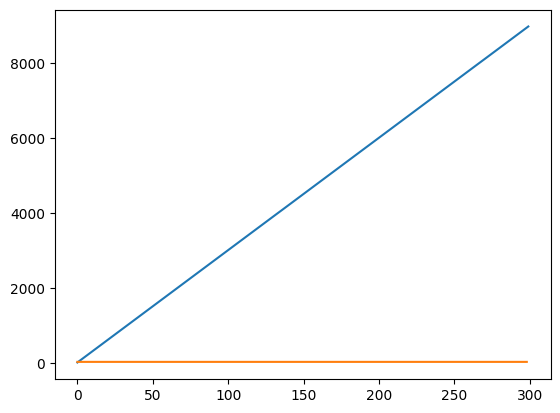

In [28]:
import re
from matplotlib import pyplot as plt
numbers = [int(n) for n in re.findall(r'-?\d+', response.text)]
plt.plot(numbers)
diffs = [b - a for a, b in zip(numbers, numbers[1:])]
print(diffs)
plt.plot(diffs)

In [30]:
drop_idxs = [i for i, v in enumerate(diffs) if v != 30]
intervals = [b - a for a, b in zip(drop_idxs, drop_idxs[1:])]
print(intervals)


[34, 33, 33, 34, 33, 33, 34]


In [32]:
drop_idxs = [i for i, v in enumerate(diffs) if v != 30]
frames_between_drops = [sum(diffs[a:b]) for a, b in zip(drop_idxs, drop_idxs[1:])]
print(frames_between_drops)


[1019, 989, 989, 1019, 989, 989, 1019]


In [33]:
fps = 30000 / 1001
interval_s = [f / fps for f in frames_between_drops]
print(interval_s)


[34.00063333333333, 32.999633333333335, 32.999633333333335, 34.00063333333333, 32.999633333333335, 32.999633333333335, 34.00063333333333]


# BURNIN TO CHECK THE VIDEO

In [7]:
import subprocess

from A_Config import set_case, case_dir

set_case(CASE_NAME)
out_dir = case_dir() / "080_experiments" / "GEMMASKTEST"
out_dir.mkdir(parents=True, exist_ok=True)

src_dir = case_dir() / "010_source"
candidates = list(src_dir.glob("*.mp4"))
assert candidates, f"no .mp4 found in {src_dir}, set VIDEO_PATH manually"
VIDEO_PATH = candidates[0]
print(f"using video: {VIDEO_PATH}")

burnin_dir = src_dir / "burnin"
burnin_dir.mkdir(parents=True, exist_ok=True)
out_path = burnin_dir / VIDEO_PATH.name

# lossless (crf 0) re-encode -- only the burned-in counter changes, frame
# content is otherwise untouched. %{n} is ffmpeg's own 0-indexed frame
# counter, +1 per encoded frame, so it matches the real frame order exactly.
drawtext = (
    "drawtext=text='%{n}':x=10:y=h-th-10:fontsize=48:"
    "fontcolor=lime:borderw=4:bordercolor=black"
)
subprocess.run(
    ["ffmpeg", "-y", "-i", str(VIDEO_PATH), "-vf", drawtext,
     "-c:v", "libx264", "-crf", "0", "-preset", "veryslow",
     "-c:a", "copy", str(out_path)],
    check=True,
)
print(f"burn-in video saved: {out_path}")


using video: /workspace/project/Data/304_met_multi_4/010_source/04.mp4


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

burn-in video saved: /workspace/project/Data/304_met_multi_4/010_source/burnin/04.mp4


[out#0/mp4 @ 0x55ba53c51680] video:248190KiB audio:468KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.005966%
frame=  609 fps= 11 q=-1.0 Lsize=  248673KiB time=00:00:24.36 bitrate=83626.1kbits/s speed=0.456x    
[libx264 @ 0x55ba5396b900] frame I:6     Avg QP: 0.00  size:554461
[libx264 @ 0x55ba5396b900] frame P:603   Avg QP: 0.00  size:415953
[libx264 @ 0x55ba5396b900] mb I  I16..4: 38.6% 12.8% 48.5%
[libx264 @ 0x55ba5396b900] mb P  I16..4: 33.7% 11.8% 22.2%  P16..4: 14.1%  3.7%  5.2%  1.9%  1.2%    skip: 6.4%
[libx264 @ 0x55ba5396b900] 8x8 transform intra:17.3% inter:21.6%
[libx264 @ 0x55ba5396b900] coded y,uvDC,uvAC intra: 77.2% 67.4% 66.9% inter: 62.7% 54.3% 53.8%
[libx264 @ 0x55ba5396b900] i16 v,h,dc,p: 39% 55%  4%  3%
[libx264 @ 0x55ba5396b900] i8 v,h,dc,ddl,ddr,vr,hd,vl,hu: 42% 44% 12%  1%  0%  0%  0%  0%  0%
[libx264 @ 0x55ba5396b900] i4 v,h,dc,ddl,ddr,vr,hd,vl,hu: 41% 41%  3%  2%  4%  3%  3%  2%  1%
[libx264 @ 0x55ba5396b900] i8c dc,h,v,p: 21% 42% 3

# NEW GEM WITH PEOPLE

In [19]:
#turn a video into a text description

from Two2D.A_gemini_v02 import gemini_vid_to_text
gem_summaries = gemini_vid_to_text(video_path, case_name, query_dir())




re_caching video
Here is a detailed summary of the events in the video:

**00:00 - 00:08**  
The video begins from the perspective of a police officer's bodycam as he walks down an alleyway lined with residential garages. Another officer is ahead of him, and they are approaching a suspect in a yellow jacket at the end of the alley. The officers repeatedly shout commands at the suspect to "put it down."

**00:08 - 00:15**  
As they get closer, the suspect is seen wielding a large sword. When one of the officers approaches, the suspect swings the weapon at him. The bodycam officer draws and fires his Taser at the suspect to neutralize the threat, but the suspect continues to struggle and strikes the officer.

**00:15 - 00:18**  
Following the violent encounter, the suspect remains standing with the sword in hand. Other officers attempt to keep their distance and contain the suspect, while the bodycam officer begins to retreat from the immediate area.

**00:18 - 00:25**  
The bodycam offi

# new roboflow test

In [3]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent.parent  # adjust if the notebook's cwd isn't src/Exploration
sys.path.insert(0, str(REPO_ROOT / "src" / "run_models"))

from spike_sam3_box_seed import main

main()


seeding person-2 ('Suspect in yellow jacket') at t=0.5s (absolute frame 12, fps=25.0), corners=[798, 50, 840, 159]


/home/vscode/.local/lib/python3.11/site-packages/inference_sdk/http/client.py:288: InferenceSDKDeprecationWarning: __init__ is experimental: WebRTC SDK is experimental and under active development. API may change in future releases. Please report issues at https://github.com/roboflow/inference/issues
  self.__webrtc_client = WebRTCClient(self.__api_url, self.__api_key)


clip_frame=1 predictions={'image': {'width': None, 'height': None}, 'predictions': []} seed_boxes={'image': {'width': None, 'height': None}, 'predictions': []}
clip_frame=3 predictions={'image': {'width': None, 'height': None}, 'predictions': []} seed_boxes={'image': {'width': None, 'height': None}, 'predictions': []}
clip_frame=4 predictions={'image': {'width': None, 'height': None}, 'predictions': []} seed_boxes={'image': {'width': None, 'height': None}, 'predictions': []}
clip_frame=5 predictions={'image': {'width': None, 'height': None}, 'predictions': []} seed_boxes={'image': {'width': None, 'height': None}, 'predictions': []}
clip_frame=6 predictions={'image': {'width': None, 'height': None}, 'predictions': []} seed_boxes={'image': {'width': None, 'height': None}, 'predictions': []}
clip_frame=7 predictions={'image': {'width': None, 'height': None}, 'predictions': []} seed_boxes={'image': {'width': None, 'height': None}, 'predictions': []}
clip_frame=8 predictions={'image': {'wid